In [1]:
#import required packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [2]:
#drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#read the csv file
df=pd.read_csv('/content/drive/MyDrive/Cognifyz/Dataset .csv')

## **Level 1**

### **Task 1: Data Exploration and Preprocessing**

In [4]:
#Data Exploration and Preprocessing
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [6]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [7]:
#identify the number of rows and columns.
df.shape

(9551, 21)

Here is 9951 rows and 21 columns

In [8]:
#Check for missing values in each column.
missing_values=df.isnull().sum()
print(missing_values)

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [9]:
#Group the dataset based on whether the 'Currency' column is in Dollar ($)
# handle missing value in currency column by using mode
#Fill missing values in each group using mode
df = df.groupby(df['Currency'] == 'Dollar($)').apply(lambda x: x.fillna(x.mode().iloc[0])).reset_index(drop=True)
(df.isnull().sum())

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


In [10]:
#check data-type
df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


columns have appropriate data types.no need to convert data-types

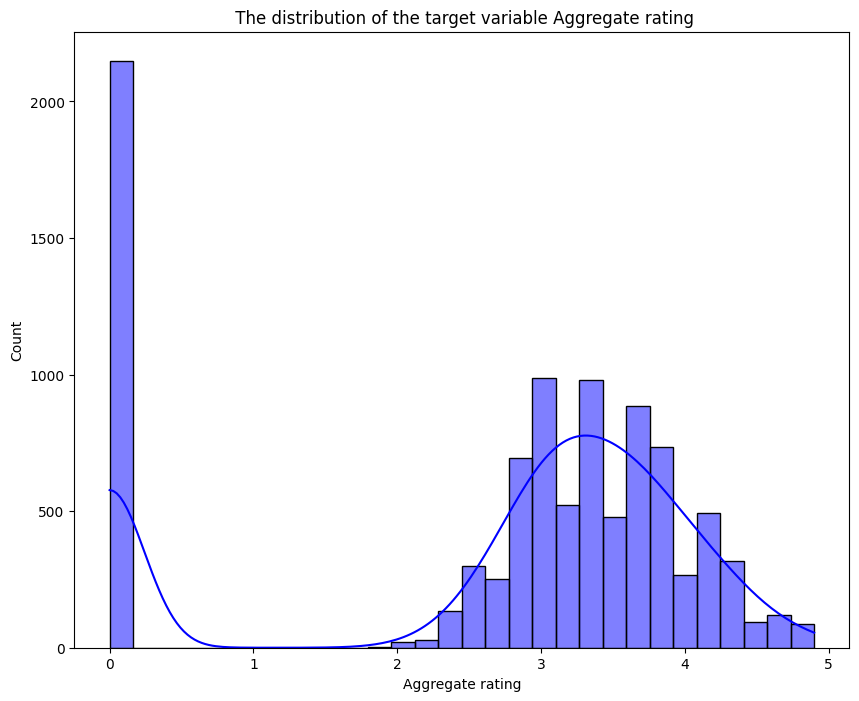

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


In [11]:
plt.figure(figsize=(10,8))
sns.histplot(df['Aggregate rating'],bins=30,kde=True,color='blue')
plt.title(' The distribution of the target variable Aggregate rating')
plt.xlabel('Aggregate rating')
plt.ylabel('Count')
plt.show()
print(df['Aggregate rating'].describe())

#**Interpretation**:
* The histogram suggests a right-skewed distribution, meaning more
restaurants have lower ratings.
* A significant number of restaurants have a rating of 0, possibly indicating missing or unrated entries.
* The majority of ratings are between 2.5 and 4.0, with fewer restaurants achieving ratings above 4.5.

In [12]:
#identify any class imbalances
rating_counts=df['Aggregate rating'].value_counts().sort_index()
print(rating_counts)
#visualize class imbalances
plt.figure(figsize=(8,6))
fig=px.bar(rating_counts,labels={'index':'Aggregate ratings','value':'count'},
           title='Class imbalances in Aggregate rating',color=rating_counts.values,color_continuous_scale='amp')
fig.show()



Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64


<Figure size 800x600 with 0 Axes>

#**Interpretation**:
1. High Presence of 0.0 Ratings (2148)
* A large portion of the dataset consists of unrated restaurants (0.0).
* This could indicate missing ratings rather than genuine low ratings.

2. Skewed Distribution:
* Ratings between 2.5 and 4.0 dominate the dataset.
* Very low ratings (below 2.5) and very high ratings (above 4.5) are significantly less frequent.
* High ratings 4.5-4.9














### **Task 2: Descriptive Analysis**

In [13]:
# Calculate basic statistical measures (mean,median, standard deviation, etc.) for numerical columns.
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


Country Code
1      8652
216     434
215      80
214      60
30       60
189      60
148      40
208      34
14       24
162      22
Name: count, dtype: int64


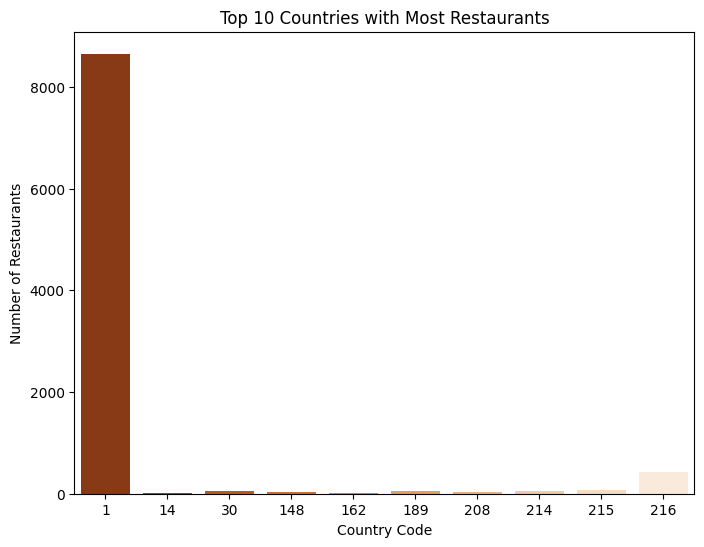

In [14]:
#top_10 countries with most Restaurants
top_countries=df['Country Code'].value_counts()
top_countries=top_countries.head(10)
print(top_countries)

plt.figure(figsize=(8,6))
sns.barplot(x=top_countries.index,y=top_countries.values,palette='Oranges_r') # Changed palette name
plt.title('Top 10 Countries with Most Restaurants')
plt.xlabel('Country Code')
plt.ylabel('Number of Restaurants')
plt.show()

## **Interpretation**


* India (Code 1) - 8,652 restaurants (over 90%)The dataset is heavily dominated by Indian restaurants, making it not globally representative.
Most insights from this dataset will be India-centric, especially for city and cuisine analysis.
Other Country Codes:
* 216 (434 restaurants) and 215 (80 restaurants) are the next highest, but they have far fewer restaurants compared to India.
The remaining countries have 60 or fewer restaurants, which is a very small sample size for meaningful comparisons.

# **Business Implications:**

1.For Restaurant Businesses:
This dataset is highly focused on India, making it useful for analyzing the Indian restaurant industry.
If the goal is to study international markets, this dataset is not ideal, as other countries have too few data points.

2. For Global Expansion Plans:
Countries like Tunisia (Code 216) and Greece (Code 30) have some restaurant presence but not enough data to draw strong conclusions.
India dominates the dataset, so any business insights will mostly apply to Indian cities.

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Bhubaneshwar      21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


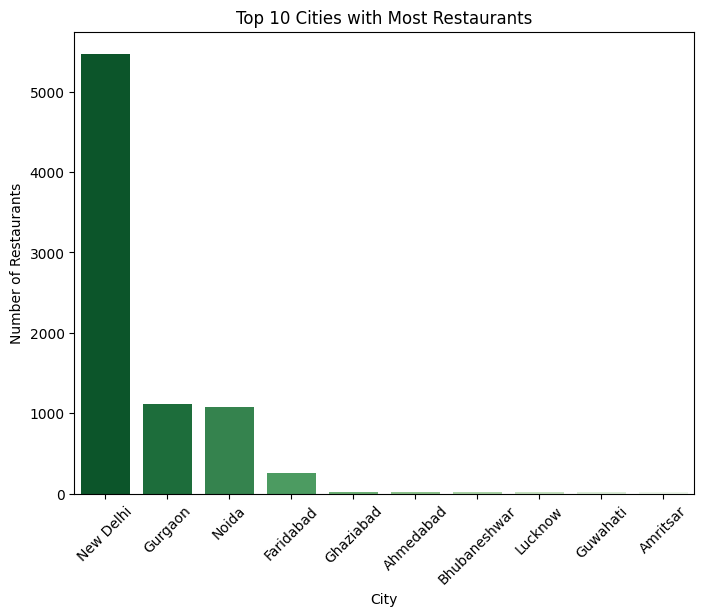

In [15]:
#top_10 cities with most Restaurants
top_cities=df['City'].value_counts()
top_cities=top_cities.head(10)
print(top_cities)
plt.figure(figsize=(8,6))
sns.barplot(x=top_cities.index,y=top_cities.values,palette='Greens_r') # Changed palette name
plt.title('Top 10 Cities with Most Restaurants')
plt.xlabel('City')
plt.xticks(rotation=45)
plt.ylabel('Number of Restaurants')
plt.show()

# Top 3 cities with the highest number of restaurants:
* New Delhi (5,473 restaurants)
* Gurgaon (1,118 restaurants)
* Noida (1,080 restaurants)
* Other cities like Faridabad, Ghaziabad, and smaller ones (e.g., Lucknow, Ahmedabad) have significantly fewer restaurants.

# **Interpretation:**


* New Delhi dominates the restaurant industry in this dataset, contributing to more than half of the total restaurants.

* The restaurant distribution suggests that the data is primarily urban-centric, focusing on major metropolitan areas.

* Smaller cities have far fewer restaurants, possibly indicating lower demand, lesser population density, or limited restaurant availability.







# Key Observations:
New Delhi (5,473 restaurants):
* Dominates the restaurant industry in this dataset.
* Being the capital city, it has a high demand for diverse cuisines and large population base.
* Likely to have intense competition among restaurants.

Gurgaon (1,118) and Noida (1,080):
* These are fast-growing urban areas near Delhi, known for corporate offices and high-income populations.
* Presence of many multinational companies increases demand for restaurants, especially in the fast food and premium dining segments.

Faridabad (251) and Ghaziabad (25):
* These cities have significantly fewer restaurants compared to Delhi, Gurgaon, and Noida.
* May indicate either lower demand or fewer high-end restaurant setups.
* Potential for restaurant expansion if demand is assessed properly.

Ahmedabad, Lucknow, Guwahati, Amritsar, Bhubaneshwar (21 each):
* These cities have a very small number of restaurants in the dataset.
* This could be due to limited data coverage or lower restaurant density.
* Cities like Ahmedabad and Lucknow have strong local food cultures, so restaurant businesses might be dominated by local food vendors rather than large chains.



# **Business Implications:**
 For New Restaurants:
* New Delhi, Gurgaon, and Noida are highly competitive but offer huge market potential.
* Niche restaurants or premium dining can succeed in corporate-heavy areas like Gurgaon.

For Expansion into Smaller Cities:
* Cities like Ahmedabad, Lucknow, and Amritsar have fewer restaurants, indicating potential for new ventures.
* However, the market demand and local food culture must be studied before entry.





Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


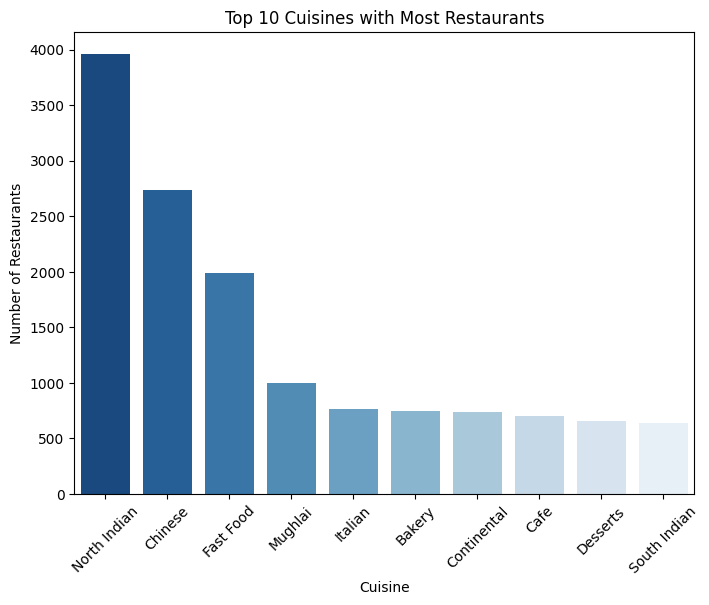

In [64]:
#top_10 cuisines with most Restaurants
top_cuisines=df['Cuisines'].str.split(', ').explode().value_counts()
top_cuisines=top_cuisines.head(10)
print(top_cuisines)

plt.figure(figsize=(8,6))
sns.barplot(x=top_cuisines.index,y=top_cuisines.values,palette='Blues_r') # Changed palette name
plt.title('Top 10 Cuisines with Most Restaurants')
plt.xlabel('Cuisine')
plt.xticks(rotation=45)
plt.ylabel('Number of Restaurants')
plt.show()

# Top 5 most common cuisines:
* North Indian (3,960 restaurants)
* Chinese (2,735 restaurants)
* Fast Food (1,986 restaurants)
* Mughlai (995 restaurants)
* Italian (764 restaurants)

# **Interpretation:**
* North Indian cuisine dominates the restaurant landscape, making it the most widely available food type. This aligns with cultural food preferences, especially in North Indian cities like Delhi, Noida, and Gurgaon.
* Chinese cuisine is the second most popular, indicating its strong presence in the Indian restaurant market despite being a foreign cuisine.
* Fast Food ranks third, showing the rising trend of quick-service restaurants, which could be due to urbanization and busy lifestyles.
* Mughlai and Italian cuisines are also notable, but their numbers are significantly lower compared to North Indian and Chinese food.


# **Business Implications:**
* New Delhi is the restaurant hub, meaning new restaurant ventures would face intense competition but also high customer demand.
* North Indian and Chinese cuisines dominate, so businesses in these segments may already be saturated, making differentiation crucial.
* Fast Food is gaining popularity, which could indicate growth opportunities in quick-service or fast-casual dining models.

* Smaller cities have fewer restaurants, which could mean lower competition, but demand assessment would be necessary before expanding.






### **Task 3: Geospatial Analysis**

In [17]:
#Visualize the locations of restaurants on a map using latitude and longitude information.
df=df[['Latitude','Longitude']]
fig=px.scatter_mapbox(df,lat='Latitude',lon='Longitude',height=600,zoom=4,mapbox_style='open-street-map')
fig.show()

# **Interpretation of the Restaurant Location Map**
If you run the provided Plotly Mapbox visualization, you will see:

Restaurant Locations:
* Each point on the map represents a restaurant based on its Latitude and Longitude.
* If there are clusters of points, it indicates a high concentration of restaurants in that area.

Geographical Distribution:
* If restaurants are spread out, they might be located across multiple cities or regions.
* If they are densely packed, it suggests a hotspot for restaurants, possibly a commercial or urban area.

Interactive Features:
* Hovering over a point will show the restaurant’s name.
* Zooming in and out will help explore specific areas in detail.

Business Insights:
* Identifying restaurant hotspots can help businesses decide where to open new locations.
* If some areas have few restaurants, they might be underserved markets with potential demand.









# **Business Implications:**
1. Identify High-Density & Low-Density Areas:
* If the map shows clusters of restaurants in certain areas, those might be competitive zones with high customer traffic.

Recommendation:
* If entering a high-density area, focus on differentiation (e.g., unique cuisine, superior service, or a niche market).
* If there are low-density areas with strong population centers, consider expansion as they might be underserved markets.

2. Expand to Underserved Areas:
* Some locations may have few or no restaurants, indicating a business opportunity.

Recommendation:
* Conduct a demand analysis (e.g., residential areas with few dining options).
* Open restaurants in growing suburbs or office hubs where competition is low.
* Focus on delivery & cloud kitchens in areas without many dine-in options.

3. Leverage High-Traffic Locations:
* If restaurants cluster around commercial hubs, shopping centers, or tourist areas, it suggests high footfall.

Recommendation:
* If your business is new, aim for footfall-heavy areas.
* If you're an existing restaurant, consider launching a food truck or satellite kitchen in high-demand zones.

4. Optimize Delivery Operations:
* Restaurants located far from urban centers may struggle with in-store foot traffic but could thrive via delivery.

Recommendation:
* Partner with food delivery services to expand reach.
* Establish dark kitchens (cloud kitchens) in key areas to serve online customers efficiently.

5. Competitive Positioning:
* If multiple restaurants are concentrated in one location, competition is high.

Recommendation:
* Stand out by offering specialized menus, promotions, or superior customer service.
* If competitors are generic fast food chains, a premium or healthy alternative might attract customers.

6. Seasonal & Tourism-Based Expansion:
* If restaurants cluster around tourist attractions, business might fluctuate seasonally.

Recommendation:
* Offer seasonal promotions to attract tourists.
* Diversify revenue streams (e.g., event catering or partnerships with local businesses).

In [18]:
top_cities = top_cities.head(10)
fig=px.bar(top_cities,labels={'index':'City','value':'Number of Restaurants'},
           title='Top 10 Cities with Most Restaurants',color=top_cities.values,color_continuous_scale='magenta')
fig.show()

## **Interpretation of the Visualization**

New Delhi Dominates the Restaurant Market:
* The number of restaurants in New Delhi is significantly higher than in other cities, exceeding 5,000.
* This suggests that New Delhi has a dense food industry, likely due to a high population and strong demand for dining options.

Gurgaon and Noida Follow as Key Players:
* Gurgaon and Noida have around 1,000 restaurants each, making them the second and third most restaurant-heavy cities in this dataset.
* This indicates strong urbanization and economic activity in these areas, likely driven by corporate offices, IT hubs, and high disposable incomes.

Other Cities Have Relatively Low Restaurant Counts:
* Cities like Faridabad, Ghaziabad, Bhubaneswar, Amritsar, Ahmedabad, Lucknow, and Guwahati have much lower restaurant numbers.
* The lower counts may be due to smaller populations, lower disposable income, or less tourism and business activity.



## **Recommendations for Business Strategy**

For Restaurant Owners & Investors:
* New Delhi is a highly competitive market but also offers a large customer base. New restaurants should focus on differentiation (e.g., unique cuisines, premium experiences, or affordability).
* Gurgaon and Noida are promising locations for opening new restaurants, given their substantial restaurant presence and growing urban populations.
* Exploring emerging cities like Ahmedabad, Lucknow, or Bhubaneswar could be a good strategy if there’s increasing demand for dining options in these areas.

For Food Delivery Services:
* Prioritize operations in New Delhi, Gurgaon, and Noida, where a large number of restaurants indicates strong demand for food delivery services.
* Expand delivery coverage in lower-ranked cities to cater to underserved markets with fewer restaurants.

For Policymakers & Urban Planners:
* Cities with lower restaurant density might need initiatives to encourage the growth of food businesses, such as licensing support and food festival promotions.
* High-density cities like New Delhi may require better infrastructure support for restaurant operations, such as waste management and traffic regulation in food hubs.

In [19]:
#city is a categorical convert to encoding
#read the csv file
df=pd.read_csv('/content/drive/MyDrive/Cognifyz/Dataset .csv')
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['city_encoded']=le.fit_transform(df['City'])
pearson_corr=df['Aggregate rating'].corr(df['city_encoded'])
print(pearson_corr)

-0.13216311013519563


A Pearson correlation value of -0.13 indicates a very weak negative correlation between the restaurant's location (City) and its Aggregate rating and The city where a restaurant is located has a minor influence on its rating. A correlation of -0.13 suggests that as the city changes, the rating slightly tends to decrease, but the effect is weak and not strong.

## **Level 2**

### **Task 1: Table Booking and Online Delivery**

In [20]:
#Determine the percentage of restaurants that offer table booking and online delivery.
percentage_table_booking = ((df['Has Table booking'] == 'Yes').sum() / df['Has Table booking'].count()) * 100
print(f"Percentage of restaurants offering table booking: {percentage_table_booking:.2f}%")

percentage_online_delivery = ((df['Has Online delivery'] == 'Yes').sum() / df['Has Online delivery'].count()) * 100
print(f"Percentage of restaurants offering online delivery: {percentage_online_delivery:.2f}%")

Percentage of restaurants offering table booking: 12.12%
Percentage of restaurants offering online delivery: 25.66%


# **Interpretation:**

Low Table Booking Availability (12.12%):
* Only about 12% of restaurants offer table booking, suggesting that the majority operate on a walk-in basis.
* This could be due to a focus on casual dining, limited seating capacity, or lower demand for reservations.

Moderate Online Delivery Availability (25.66%):
* Around 25.66% of restaurants provide online delivery, indicating that while some restaurants embrace online ordering, the majority still rely on in-house dining.
* This could be due to operational constraints, lack of delivery infrastructure, or a focus on premium dine-in experiences.

## **Business Recommendations:**

For Restaurants Without Table Booking:
* If feasible, implementing a reservation system can enhance customer experience, reduce waiting times, and attract more dine-in customers.
* Partnering with platforms like OpenTable, Zomato, or in-house booking apps can streamline the process.

For Restaurants Without Online Delivery:

* Given the increasing demand for food delivery, restaurants should consider collaborating with platforms like Swiggy, Zomato, or Uber Eats.
* Investing in their own delivery service could help increase sales, especially in high-demand areas.

For Data-Driven Decision Making:
* Further analysis can be done to see if restaurants that offer table booking or online delivery have higher ratings and customer engagement.
* A/B testing can help evaluate the impact of introducing table reservations or delivery services on revenue.

In [21]:
#Compare the average ratings of restaurants with table booking and those without.
avg_rating_with_table_booking=df[df['Has Table booking']=='Yes']['Aggregate rating'].mean()
print(f'average ratings of restaurants with table booking: {avg_rating_with_table_booking:.2f}')
avg_rating_without_table_booking=df[df['Has Table booking']=='No']['Aggregate rating'].mean()
print(f'average ratings of restaurants without table booking: {avg_rating_without_table_booking:.2f}')

average ratings of restaurants with table booking: 3.44
average ratings of restaurants without table booking: 2.56


# **Interpretation:**
* Restaurants that offer table booking tend to have higher average ratings compared to those that do not.
* This suggests that restaurants with reservations may provide a better dining experience, such as improved service, ambiance, or overall quality.
* Customers may also perceive table booking as a feature of higher-end or well-managed restaurants, leading to better reviews.



# **Business Recommendations:**
For Restaurants With Table Booking:
* Maintain high service standards to continue receiving positive ratings.
* Leverage the higher ratings in marketing strategies to attract more customers.

For Restaurants Without Table Booking:
* Consider implementing a reservation system to enhance customer experience and potentially boost ratings.
* Partner with booking platforms like OpenTable or Zomato to streamline the process.


Online Delivery Availability by: Price range
1    15.77
2    41.31
3    29.19
4     9.04
Name: Has Online delivery, dtype: float64


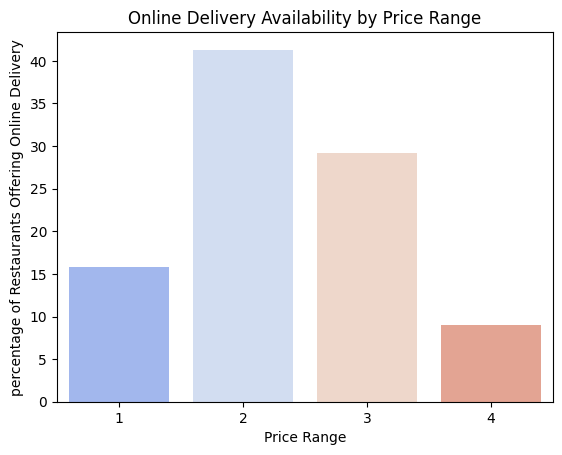

In [22]:
#Analyze the availability of online delivery among restaurants with different price ranges.
online_delivery = df.groupby("Price range")["Has Online delivery"].apply(lambda x: (x == "Yes").mean() * 100).round(2)
print(f'Online Delivery Availability by: {online_delivery}')

sns.barplot(x=online_delivery.index, y=online_delivery.values, palette="coolwarm", alpha=0.8)
plt.xlabel("Price Range")
plt.ylabel("percentage of Restaurants Offering Online Delivery")
plt.title("Online Delivery Availability by Price Range")
plt.show()

**Assuming Price range**


* Price range 1 & 4 : Low cost with online delivery
* Price range 2 : Budget-friendly cost with online delivery
* Price range 3 : Mid-range cost with online delivery

## **Interpretation:**
* Budget-friendly restaurants (Price Range 2) have the highest online delivery availability (41.31%), suggesting that affordability attracts more online customers.

* Mid-range restaurants(Price range 3) (29.19%) also offer a fair amount of online delivery, but not as much as budget-friendly ones.

* Low-cost(Price range 1 & 4) (15.77%) and expensive (9.04%) restaurants have the lowest online delivery availability.

* Low-cost restaurants may not have enough infrastructure for delivery.

* Expensive restaurants may focus more on premium dine-in experiences rather than delivery.



# **Business Recommendations**:
For Low-cost Restaurants:
* Consider partnering with food delivery platforms to expand reach, as demand for affordable online food is growing.

For Budget-Friendly & Mid-Range Restaurants:
* Continue leveraging online delivery, as it is a significant revenue channel.
* Optimize packaging and delivery services to enhance customer experience.

For Expensive Restaurants:
* If feasible, offer a premium online dining experience with well-packaged, high-quality food for special occasions.
* Highlight exclusivity through limited online delivery offerings.

### **Task 2: Price Range Analysis**

In [23]:
#Determine the most common price range among all the restaurants.
most_common_price_range = df["Price range"].mode()[0]
print("Most Common Price Range:", most_common_price_range)

Most Common Price Range: 1


# **Interpretation:**
* The most common price range among all restaurants is 1 (Low-cost), meaning that the majority of restaurants in the dataset are affordable.
* This suggests that customers generally prefer budget-friendly dining options over mid-range or expensive restaurants.
* The distribution might reflect customer demand, purchasing power, or competitive pricing strategies in the region.

Average Ratings by : Price range
1    2.00
2    2.94
3    3.68
4    3.82
Name: Aggregate rating, dtype: float64


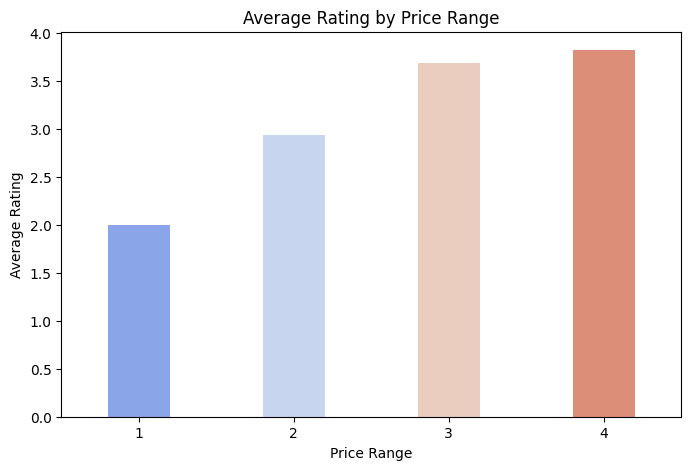

In [24]:
# Calculate the average rating for each price range.
avg_rating_by_price_range = df.groupby("Price range")["Aggregate rating"].mean().round(2)
print(f'Average Ratings by : {avg_rating_by_price_range}')

#Identify the color that represents the highest average rating among different price ranges.
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_rating_by_price_range.index, y=avg_rating_by_price_range.values, palette="coolwarm",width=0.4)
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.title("Average Rating by Price Range")
plt.show()

# **Interpretation:**

* Higher-priced restaurants generally have higher average ratings compared to lower-priced ones.
* This suggests that customers associate higher prices with better food quality, service, and dining experience.
* If low-cost restaurants have significantly lower ratings, this may indicate service issues, inconsistent food quality, or lower customer expectations.



# **Business Recommendations:**

For Low-Cost Restaurants:
* Improve food quality and hygiene to enhance customer satisfaction.
* Train staff for better customer service to compete with higher-rated restaurants.
* Encourage positive reviews by offering small incentives (e.g., discounts, loyalty points).

For Mid-Range Restaurants:
* Maintain a balance between price and quality to attract budget-conscious yet quality-seeking customers.
* Differentiate with unique dishes or themes to stand out in the competition.
* Leverage digital marketing (social media, promotions) to reach more customers.

For High-End Restaurants:
* Use strong ratings as a selling point in marketing to justify premium pricing.
* Offer personalized experiences (chef’s specials, exclusive menus) to maintain high customer satisfaction.
* Maintain consistent service quality to sustain positive reviews and high ratings.

### **Task 3: Feature Engineering**

In [25]:
# Extract additional features from the existing columns, such as the length of the restaurant name or address.
df['Restaurant Name Length'] = df['Restaurant Name'].apply(len)
df['Address Length'] = df['Address'].apply(len)
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,city_encoded,Restaurant Name Length,Address Length
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,No,No,3,4.8,Dark Green,Excellent,314,73,16,71
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,No,No,3,4.5,Dark Green,Excellent,591,73,16,67
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,No,No,4,4.4,Green,Very Good,270,75,22,56
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,4,4.9,Dark Green,Excellent,365,75,4,70
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,No,No,4,4.8,Dark Green,Excellent,229,75,11,64


In [26]:
#Create new features like "Has Table Booking" or "Has Online Delivery" by encoding categorical variables.
df['Has_Table_Booking'] = le.fit_transform(df['Has Table booking'])
df['Has_Online_Delivery'] = le.fit_transform(df['Has Online delivery'])
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Price range,Aggregate rating,Rating color,Rating text,Votes,city_encoded,Restaurant Name Length,Address Length,Has_Table_Booking,Has_Online_Delivery
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,3,4.8,Dark Green,Excellent,314,73,16,71,1,0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,3,4.5,Dark Green,Excellent,591,73,16,67,1,0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,4,4.4,Green,Very Good,270,75,22,56,1,0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,4,4.9,Dark Green,Excellent,365,75,4,70,0,0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,4,4.8,Dark Green,Excellent,229,75,11,64,1,0


## **Level 3**

### **Task 1: Predictive Modeling**

1. Build a regression model to predict the
 aggregate rating of a restaurant based on
 available features.
 Split the dataset into training and testing sets
 and evaluate the model's performance using
 appropriate metrics.



In [27]:
df.head()
# encoding cuisines column
df['cuisines_encoded']=le.fit_transform(df['Cuisines'])
df['Is delivering now_encoded']=le.fit_transform(df['Is delivering now'])
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Rating color,Rating text,Votes,city_encoded,Restaurant Name Length,Address Length,Has_Table_Booking,Has_Online_Delivery,cuisines_encoded,Is delivering now_encoded
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Dark Green,Excellent,314,73,16,71,1,0,920,0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Dark Green,Excellent,591,73,16,67,1,0,1111,0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Green,Very Good,270,75,22,56,1,0,1671,0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Dark Green,Excellent,365,75,4,70,0,0,1126,0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Dark Green,Excellent,229,75,11,64,1,0,1122,0


In [28]:
#drop unnecessary features
x=df[['Country Code','Longitude','Latitude','Average Cost for two','Price range','Votes','Has_Table_Booking',
      'Has_Online_Delivery', 'cuisines_encoded','Is delivering now_encoded']]
y=df['Aggregate rating']

In [29]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

In [31]:
from scipy import stats
import statsmodels.api as sm
x_train_with_const=sm.add_constant(x_train)
x_test_with_const=sm.add_constant(x_test)

In [32]:
model=sm.OLS(y_train,x_train_with_const)
results=model.fit()

In [33]:
y_pred=results.predict(x_test_with_const)
print("Model Summary:")
print(results.summary())

Model Summary:
                            OLS Regression Results                            
Dep. Variable:       Aggregate rating   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     339.5
Date:                Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:08:23   Log-Likelihood:                -12624.
No. Observations:                7640   AIC:                         2.527e+04
Df Residuals:                    7629   BIC:                         2.535e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6601      0.014    1

# Your Multiple Linear Regression model has been trained, and here’s a breakdown of its performance:

1. Model Performance:
* R-squared (R²) = 0.308 → The model explains 30.8% of the variance in aggregate ratings, which is quite low.

* Adjusted R² = 0.307 → Similar to R², meaning adding more features didn’t significantly improve performance.

* F-statistic = 339.5 (p-value = 0.000) → The overall model is statistically significant.

2. Coefficients & Significance
Significant Features (p < 0.05):

* x1 (0.3854, p = 0.000) → Strong positive impact.

* x2, x3, x5, x6, x8 → Significant positive effect.

* x9 (-0.0650, p = 0.000) → Significant negative impact.

Non-Significant Features (p > 0.05)

* x4 (p = 0.278), x7 (p = 0.497), x10 (p = 0.804)

These features have no meaningful impact on the target variable and could be removed.

In [34]:
from sklearn.metrics import mean_squared_error, r2_score
r2=r2_score(y_test,y_pred)
print(f'R-squared (R²): {r2}')
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Root Mean Squared Error
rmse_normalized = rmse / (y.max() - y.min())
print(f'rmse_normalized (RMSE_Normalized) on test data: {rmse_normalized}')

R-squared (R²): 0.29800117961592176
rmse_normalized (RMSE_Normalized) on test data: 0.2579696641392398


# **Analysis of multiple regression Model Performance:**
* R² = 0.298 → The model explains only 29.8% of the variance in restaurant ratings, meaning it does not fit the data well.

* Normalized RMSE = 0.258 → Indicates a moderate level of error relative to the target variable’s range.

What This Means?
🔹 The low R² suggests that Linear Regression is not capturing the complexity of the data well.


2.  Experiment with different algorithms (e.g.,
 linear regression, decision trees, random
 forest) and compare their performance



## **Decision trees**

In [35]:
from sklearn.tree import DecisionTreeRegressor

In [36]:
from sklearn.model_selection import GridSearchCV
# Grid search for max_depth
param_grid = {'max_depth': range(1, 21)}  # Try depths from 1 to 20
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=0), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(x_train, y_train)

# Best max_depth found
print("Best max_depth:", grid_search.best_params_['max_depth'])

Best max_depth: 7


In [37]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor(random_state = 0,max_depth= 7)

regressor.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=7, random_state=0)

In [38]:
y_pred = regressor.predict(x_test)

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MAE: 0.21003557078353494
MSE: 0.10191000668030187
RMSE: 0.3192334673562624
R²: 0.9552262184657312


# **Decision Tree Regression Performance:**
* MAE = 0.210 → The average absolute error is low, meaning predictions are close to actual ratings.

* MSE = 0.102 → The model has low squared error, indicating good performance.

* RMSE = 0.319 → The root mean squared error is small, reinforcing low prediction error.

* R² = 0.955 → The model explains 95.5% of the variance, which is a huge improvement over Linear Regression (R² = 0.298).

## **Random Forest**

In [40]:
# Initialize Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1, max_depth=5, n_estimators=100, oob_score=True)

In [41]:
# Train the model
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [42]:
# Evaluate Out-of-Bag score
print(f"Out-of-Bag Score: {rf.oob_score_:.4f}")

Out-of-Bag Score: 0.9519


In [43]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'max_depth': [2, 3, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100, 200],
    'n_estimators': [10, 25, 30, 50, 100, 200]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=4,
                           n_jobs=-1, verbose=1, scoring="neg_mean_squared_error")

In [44]:
# Fit GridSearch on training data
grid_search.fit(x_train, y_train)
grid_search.best_params_

Fitting 4 folds for each of 180 candidates, totalling 720 fits


{'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}

In [45]:
# Best model from GridSearchCV
rf_best = grid_search.best_estimator_

In [46]:
y_pred = rf_best.predict(x_test)

In [47]:
test_mse = mean_squared_error(y_test, y_pred)
print(f"Test Mean Squared Error: {test_mse:.4f}")
test_mae=mean_absolute_error(y_test, y_pred)
print(f"Test Mean Absolute Error: {test_mae:.4f}")
test_r2=r2_score(y_test, y_pred)
print(f"Test R²: {test_r2:.4f}")

Test Mean Squared Error: 0.0859
Test Mean Absolute Error: 0.1910
Test R²: 0.9622


# **Random Forest Regression Performance:**
* Test MSE = 0.0859 → Even lower than Decision Tree, indicating a better fit.

* Test MAE = 0.1910 → Lower than Decision Tree (0.2100), meaning predictions are more precise.

* Test R² = 0.9622 → Explains 96.2% of the variance, slightly better than Decision Tree (R² = 0.955).

* Out-of-Bag (OOB) Score = 0.9519 → Confirms that the model generalizes well to unseen data.

Key Insights:
* Random Forest outperforms both Linear Regression and Decision Tree Regression.
* Less overfitting compared to a single Decision Tree (because it averages multiple trees).
* Best model so far for predicting restaurant aggregating ratings! 🎯

# **Model Performance Analysis and Selection**
**1. Multiple Regression Model Performance:**
* R² = 0.298 → The model explains only 29.8% of the variance in restaurant ratings, meaning it does not fit the data well.
* Normalized RMSE = 0.258 → Indicates a moderate level of error relative to the target variable’s range.

**2. Decision Tree Regression Performance:**
* MAE = 0.210 → The average absolute error is low, meaning predictions are close to actual ratings.
* MSE = 0.102 → The model has low squared error, indicating good performance.
* RMSE = 0.319 → The root mean squared error is small, reinforcing low prediction error.
* R² = 0.955 → The model explains 95.5% of the variance, which is a huge improvement over Linear Regression (R² = 0.298).

**3. Random Forest Regression Performance:**
* Test MSE = 0.0859 → Even lower than Decision Tree, indicating a better fit.
* Test MAE = 0.1910 → Lower than Decision Tree (0.2100), meaning predictions are more precise.
* Test R² = 0.9622 → Explains 96.2% of the variance, slightly better than Decision Tree (R² = 0.955).
* Out-of-Bag (OOB) Score = 0.9519 → Confirms that the model generalizes well to unseen data.

# **Best Model Selection: Random Forest Regression**
**Based on the performance metrics, Random Forest Regression is the best model because:**

* Highest R² (0.9622) → Explains the most variance in restaurant ratings.
* Lowest Error (MSE & MAE) → More precise predictions than other models.
* less Overfitting → Unlike Decision Trees, Random Forest averages multiple trees, reducing variance.
* Out-of-Bag (OOB) Score = 0.9519 → Confirms it generalizes well to new data.

# **Final Conclusion🏆:**
* The Random Forest Regression model is the best choice because it provides the most accurate predictions while avoiding overfitting.
* It outperforms both Linear Regression and Decision Tree models in terms of accuracy, generalization, and error reduction.


### **Task 2: Customer Preference Analysis**

Top 15 Cuisines by Average Rating:
          Cuisines  Aggregate rating
130          Sunda          4.900000
26          B�_rek          4.700000
132      Taiwanese          4.650000
112          Ramen          4.500000
43         Dim Sum          4.466667
61        Hawaiian          4.412500
47          D�_ner          4.400000
23      Bubble Tea          4.400000
40           Curry          4.400000
75           Kebab          4.380000
71          Izgara          4.350000
50        Filipino          4.340000
121  South African          4.333333
117       Scottish          4.333333
140  Turkish Pizza          4.325000


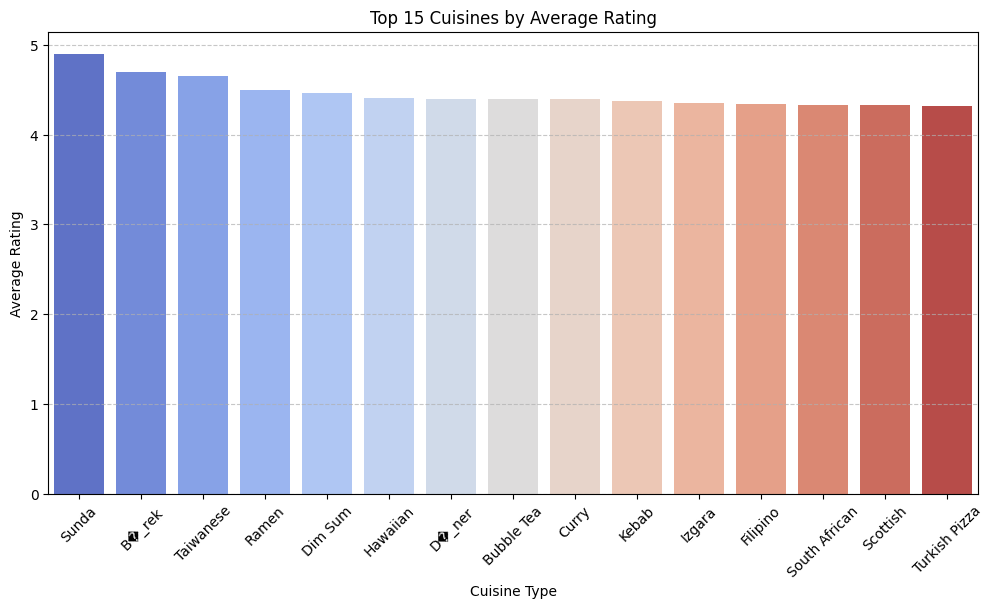

In [80]:
# Explode the cuisines column to handle multiple cuisines per restaurant
df_expanded = df.assign(Cuisines=df["Cuisines"].str.split(", ")).explode("Cuisines")

# Clean cuisine names by removing unnecessary brackets and quotes
df_expanded["Cuisines"] = df_expanded["Cuisines"].str.strip("[]'")

# Calculate the average rating per cuisine type
cuisine_ratings = df_expanded.groupby("Cuisines")["Aggregate rating"].mean().reset_index().sort_values(by='Aggregate rating', ascending=False)

# Display the top 15 cuisines with the highest average ratings
print("Top 15 Cuisines by Average Rating:")
print(cuisine_ratings.head(15))

# Visualization using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=cuisine_ratings.head(15), x='Cuisines', y='Aggregate rating', palette='coolwarm')
plt.title("Top 15 Cuisines by Average Rating")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# **Analysis of the Relationship Between Cuisine Type and Restaurant Rating**
**The dataset shows the average ratings for various cuisines, providing insight into how cuisine type impacts customer satisfaction. Here are key takeaways from the data:**

1. Highest-Rated Cuisines
* Sunda (4.90): This Indonesian cuisine has the highest rating, suggesting high customer satisfaction.
* Börek (4.70): A popular Turkish pastry, indicating strong positive reception.
* Taiwanese (4.65): Known for bold flavors, bubble tea, and street food, contributing to high ratings.

2. Trend Among Highly Rated Cuisines
* Authenticity & Specialty: Cuisines that are deeply rooted in traditional cooking, such as Sunda, Taiwanese, and Turkish, tend to have higher ratings.
* Street Food Influence: Items like Ramen, Dim Sum, Bubble Tea, and Kebab suggest that casual, flavorful, and widely available street foods resonate well with customers.
* Regional Variations: African, Hawaiian, and South African cuisines also rank highly, indicating a growing appreciation for diverse flavors.

3. Factors Influencing Cuisine Ratings
* Cultural Popularity: Well-known cuisines such as Ramen, Kebab, and Curry are globally recognized, leading to consistent demand and positive experiences.
* Quality vs Accessibility: While niche cuisines have high ratings, accessibility and availability might limit the number of restaurants serving them.
* Fusion & Modern Twists: Cuisines like Turkish Pizza and Filipino show how traditional foods adapted for broader audiences can still maintain strong ratings.

4. Insights for Businesses
* Investment in Authenticity: Restaurants focusing on authentic, traditional preparations tend to receive higher ratings.
* Incorporating Popular Flavors: Businesses can explore adding elements from high-rated cuisines, like Ramen or Bubble Tea, to diversify their offerings.
* Localization of Foreign Cuisines: More exposure and marketing of lesser-known but high-rated cuisines (e.g., Sunda and Börek) could drive customer interest.

**Conclusion**
There is a clear relationship between cuisine type and restaurant ratings, where:

* Traditional and niche cuisines tend to receive higher ratings.
* Popular street-food-based cuisines (e.g., Dim Sum, Ramen, Kebab) are widely enjoyed.
* The overall dining experience, influenced by authenticity, presentation, and uniqueness, significantly impacts ratings.

Top 15 Cuisines by Vote:
          Cuisines   Votes
100   North Indian  595981
34         Chinese  364351
70         Italian  329265
37     Continental  288255
49       Fast Food  184058
2         American  183117
27            Cafe  177568
95         Mughlai  151946
42        Desserts  105889
7            Asian  104303
48        European  103309
123   South Indian   80962
87   Mediterranean   80538
108          Pizza   78179
24          Burger   76747


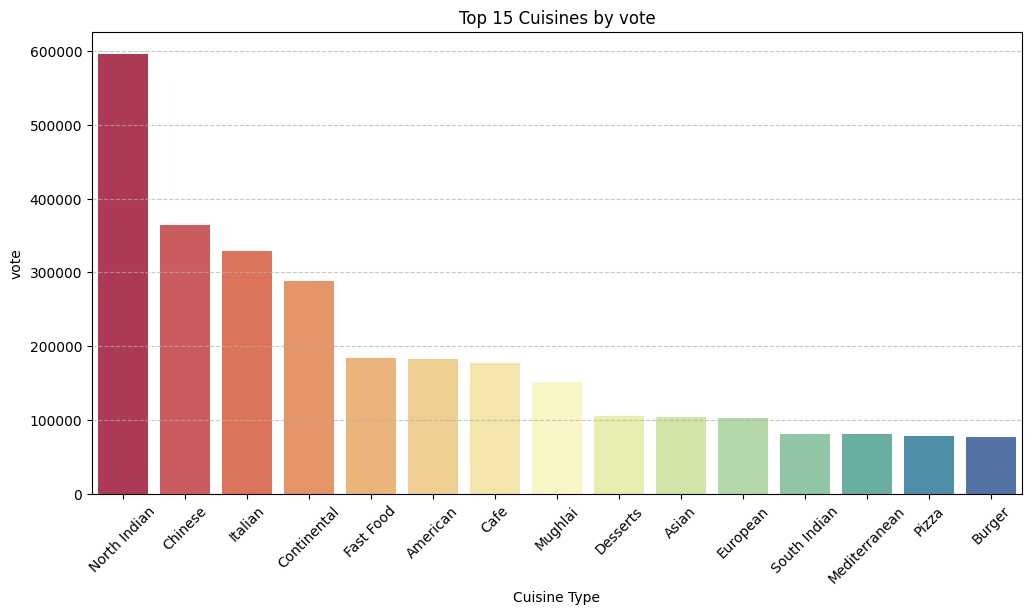

In [91]:
# Identify the most popular cuisines among customers based on the number of votes.
cuisine_vote = df_expanded.groupby("Cuisines")["Votes"].sum().reset_index().sort_values(by='Votes', ascending=False)

# Display the top 15 cuisines with the highest vote
print("Top 15 Cuisines by Vote:")
print(cuisine_vote.head(15))

# Visualization using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=cuisine_vote.head(15), x='Cuisines', y='Votes', palette='Spectral')
plt.title("Top 15 Cuisines by vote")
plt.xlabel("Cuisine Type")
plt.ylabel("vote")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# **Most Popular Cuisines Among Customers Based on Votes**
**The popularity of a cuisine can be measured by the total number of votes it has received from customers. The higher the votes, the more customers have engaged with restaurants offering that cuisine.**

Top 5 Most Popular Cuisines:
* North Indian (595,981 votes) – A dominant choice, known for its rich gravies, spices, and tandoori dishes.

* Chinese (364,351 votes) – A global favorite with diverse flavors, including noodles, dumplings, and stir-fries.

* Italian (329,265 votes) – Driven by pizza, pasta, and other Mediterranean-inspired dishes.

* Continental (288,255 votes) – A broad category covering European-style dishes, widely preferred in urban areas.

* Fast Food (184,058 votes) – Includes burgers, fries, and other quick-serve meals, reflecting high demand for convenience.

Other Highly Popular Cuisines:
* American (183,117 votes): Burgers, steaks, and classic comfort food drive its popularity.

* Cafe (177,568 votes): Reflects a growing coffee culture and casual dining experiences.

* Mughlai (151,946 votes): Known for its rich, royal flavors like biryanis and kebabs.

* Desserts (105,889 votes): Highlights the universal love for sweets and baked goods.

* South Indian (80,962 votes): A staple cuisine featuring dosas, idlis, and sambhar.

# **Business Recommendations:**
* Optimize Menus – Focus on popular cuisines and introduce fusion dishes to attract diverse customers.
* Boost Marketing – Promote high-demand cuisines with social media campaigns, seasonal offers, and discounts.
* Expand Smartly – Open fast food and cafe-style outlets in high-traffic areas and invest in cloud kitchens for online delivery.
* Enhance Customer Experience – Use loyalty programs, personalized recommendations, and authentic recipes to retain customers.

Top 5 Cuisines by Average Rating:
      Cuisines  Aggregate rating
130      Sunda          4.900000
26      B�_rek          4.700000
132  Taiwanese          4.650000
112      Ramen          4.500000
43     Dim Sum          4.466667


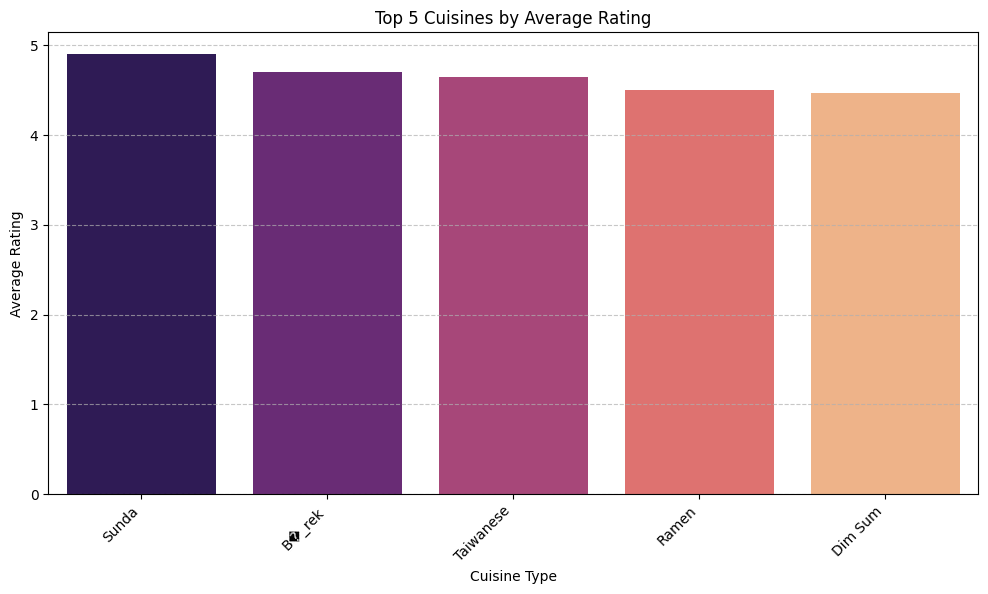

In [97]:
 #Determine if there are any specific cuisines that tend to receive higher ratings

# Calculate the average rating per cuisine type
cuisine_ratings = df_expanded.groupby("Cuisines")["Aggregate rating"].mean().reset_index().sort_values(by='Aggregate rating', ascending=False)

# Display the top 15 cuisines with the highest average ratings
print("Top 5 Cuisines by Average Rating:")
print(cuisine_ratings.head(5))

# Visualization using Seaborn for ratings
plt.figure(figsize=(12, 6))
sns.barplot(data=cuisine_ratings.head(5), x='Cuisines', y='Aggregate rating', palette='magma')
plt.title("Top 5 Cuisines by Average Rating")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Top 5 Highest-Rated Cuisines**
* Sunda (4.90) – Likely due to its unique flavors and authenticity.
* Börek (4.70) – A well-loved Turkish pastry, possibly rated high for its texture and taste.
* Taiwanese (4.65) – Popular for its balance of flavors, street food, and bubble tea.
* Ramen (4.50) – Consistently favored, likely due to its comforting and customizable nature.
* Dim Sum (4.47) – A highly diverse and flavorful cuisine, appealing to a broad audience.

# **Business Insights & Recommendations:**
* Capitalize on Highly Rated Cuisines – Restaurants should highlight top-rated cuisines in marketing and promotions.
* Offer Premium Experiences – Since these cuisines are highly rated, customers may be willing to pay more for authentic, high-quality ingredients.
* Expand Menu Offerings – Restaurants can introduce specialized sections or limited-time offers featuring these cuisines.
* Leverage Customer Reviews – Use positive feedback and testimonials to attract new customers and build trust.

### **Task 3: Data Visualization**

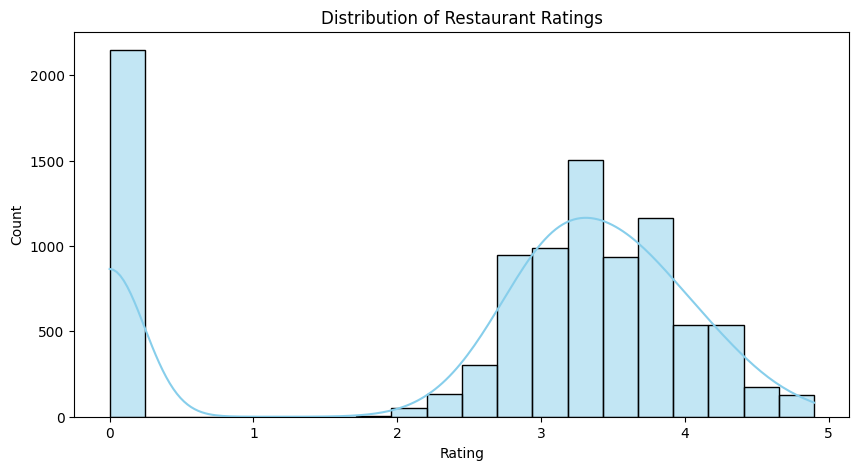

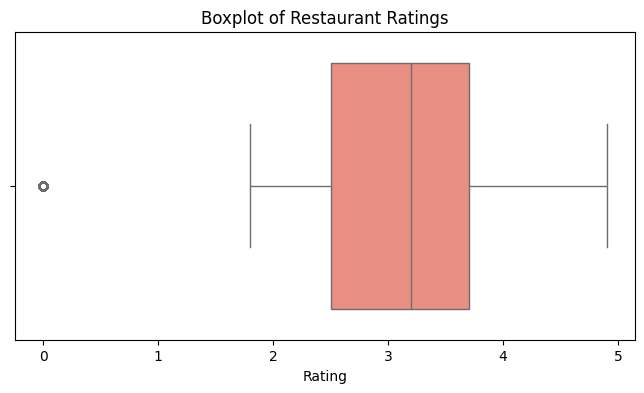

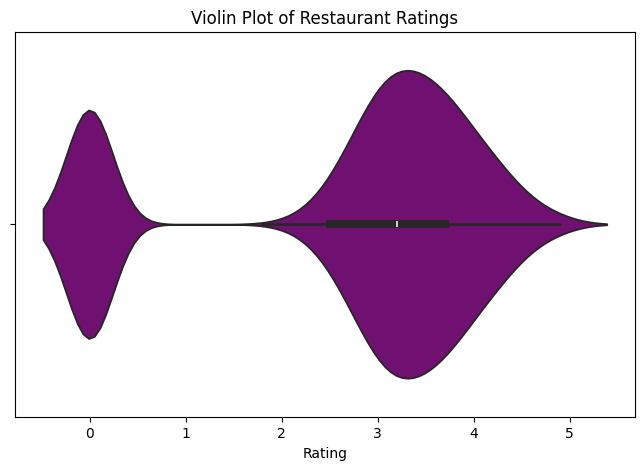

In [100]:
# Create visualizations to represent the distribution of ratings using different charts (histogram, barplot, etc.).
# Histogram of Ratings
plt.figure(figsize=(10, 5))
sns.histplot(df["Aggregate rating"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Boxplot of Ratings
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Aggregate rating"], color="salmon")
plt.title("Boxplot of Restaurant Ratings")
plt.xlabel("Rating")
plt.show()

# Violin Plot of Ratings
plt.figure(figsize=(8, 5))
sns.violinplot(x=df["Aggregate rating"], color="purple")
plt.title("Violin Plot of Restaurant Ratings")
plt.xlabel("Rating")
plt.show()


# **These visualizations provide different perspectives on restaurant ratings:**
* **Histogram:** Shows the frequency distribution of ratings. A large concentration of ratings around 3–4 suggests most restaurants receive moderate to good reviews.
* **Boxplot:** Highlights the spread of ratings and outliers. The presence of low ratings at 0 might indicate missing or unrated restaurants.
* **Violin Plot:** Provides a smoothed density estimation, emphasizing rating distribution.

       Cuisines  Aggregate rating
130       Sunda          4.900000
26       B�_rek          4.700000
132   Taiwanese          4.650000
112       Ramen          4.500000
43      Dim Sum          4.466667
61     Hawaiian          4.412500
47       D�_ner          4.400000
23   Bubble Tea          4.400000
40        Curry          4.400000
75        Kebab          4.380000


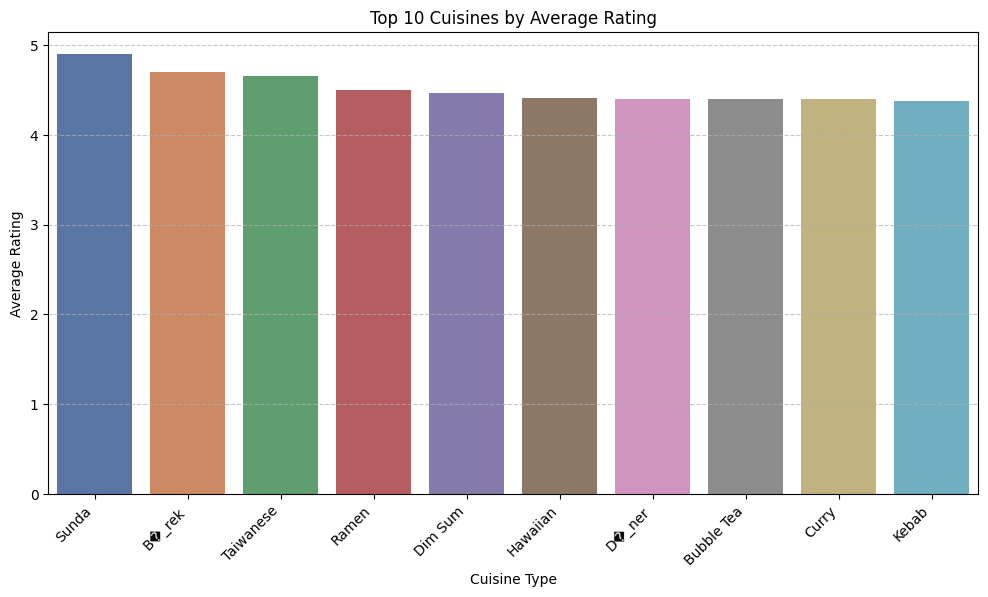

                 City  Aggregate rating
56         Inner City          4.900000
107       Quezon City          4.800000
73        Makati City          4.650000
95         Pasig City          4.633333
75   Mandaluyong City          4.625000
15         Beechworth          4.600000
67             London          4.535000
123       Taguig City          4.525000
116      Secunderabad          4.500000
66            Lincoln          4.500000


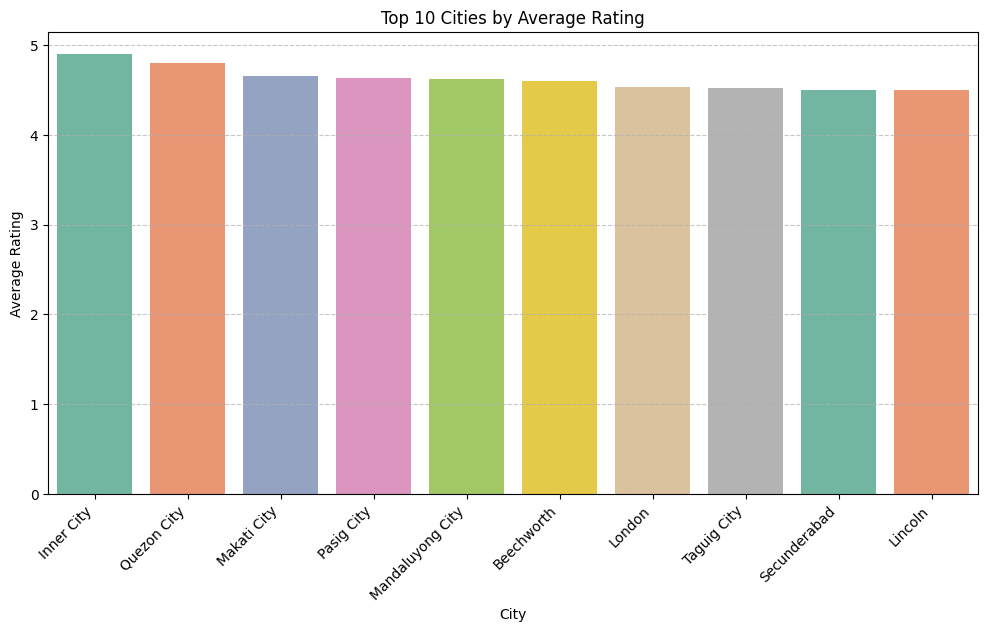

In [106]:
# Compare the average ratings of different cuisines or cities using appropriate visualizations.

# Compare Average Ratings by Cuisine
cuisine_ratings = df_expanded.groupby("Cuisines")["Aggregate rating"].mean().reset_index().sort_values(by='Aggregate rating', ascending=False)
print(cuisine_ratings.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=cuisine_ratings.head(10), x='Cuisines', y='Aggregate rating', palette='deep')
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Compare Average Ratings by City
city_ratings = df.groupby("City")["Aggregate rating"].mean().reset_index().sort_values(by='Aggregate rating', ascending=False)
print(city_ratings.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=city_ratings.head(10), x='City', y='Aggregate rating', palette='Set2')
plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **Comparison: Cuisine-Wise vs. City-Wise Ratings**
**1. Cuisine-Wise Ratings:**
* Sunda, Börek, and Taiwanese cuisines receive the highest ratings, suggesting a preference for these specific flavors or authentic preparation styles.
* Ramen, Dim Sum, and Hawaiian also perform well, indicating strong demand for Asian and fusion cuisines.
* Cuisines with rich flavors and cultural heritage tend to receive higher ratings.

**2.  City-Wise Ratings:**
* Inner City, Quezon City, and Makati City have the highest restaurant ratings, indicating strong demand for quality dining experiences.
* London and Secunderabad also maintain high ratings, suggesting a well-developed food industry with diverse cuisine offerings.
* Cities with higher ratings may have more premium restaurants, while others might have casual eateries with a mix of customer experiences.





# **Business Recommendations**
* **Expand High-Rated Cuisines** – Focus on offering Sunda, Taiwanese, and Ramen, as they have the highest customer ratings, ensuring strong demand.

* **Target High-Rating Cities** – Cities like Inner City, Quezon City, and Makati City have top ratings, making them ideal for new restaurant openings or premium dining experiences.

* **Improve Presence in Emerging Markets** – Cities like Taguig and Secunderabad show strong ratings, indicating potential for growth and investment in these areas.

* **Enhance Customer Experience** – In lower-rated cities, restaurants should improve food quality, service, and ambiance to boost ratings and attract more customers.

* **Data-Driven Menu Optimization** – Use customer insights to refine menu offerings based on high-demand cuisines, ensuring better engagement and increased revenue.

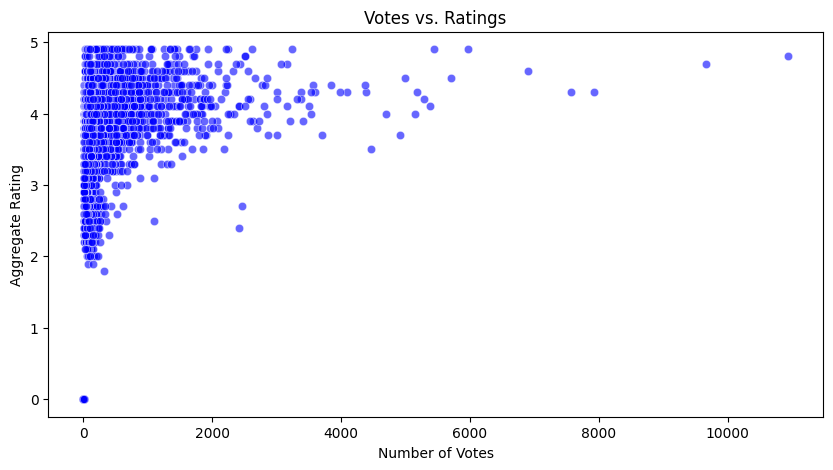

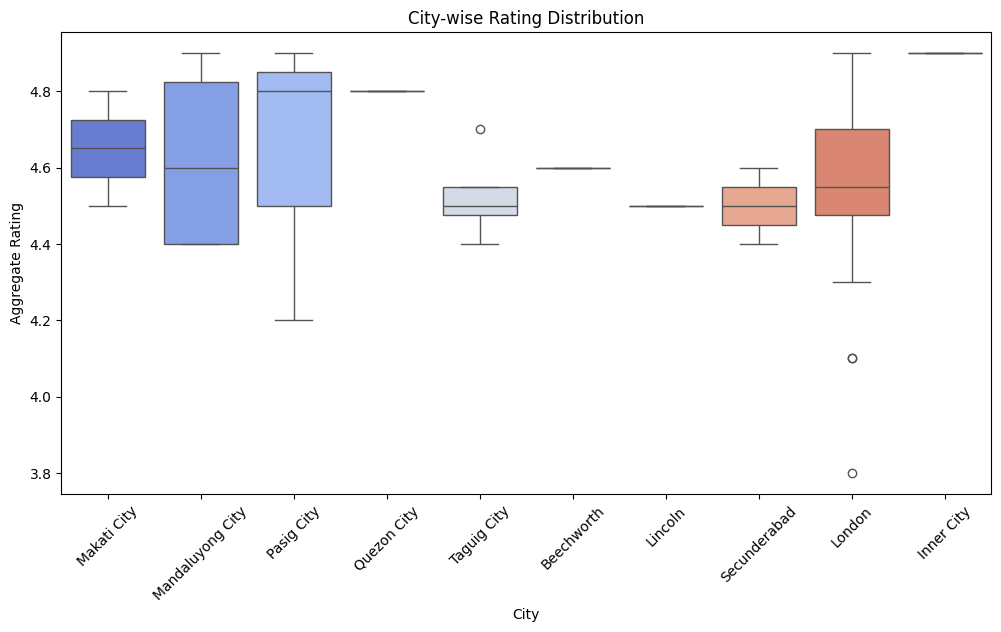

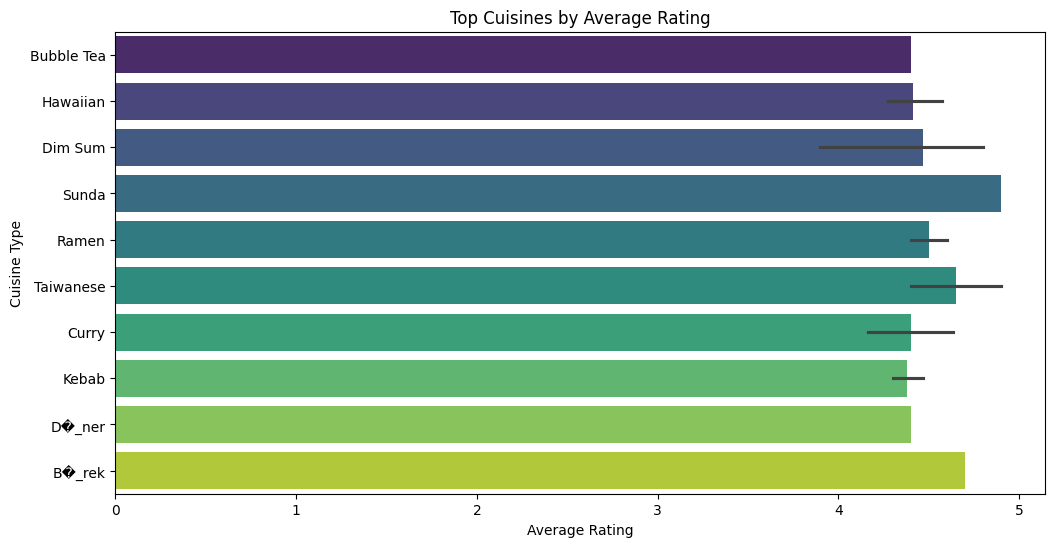

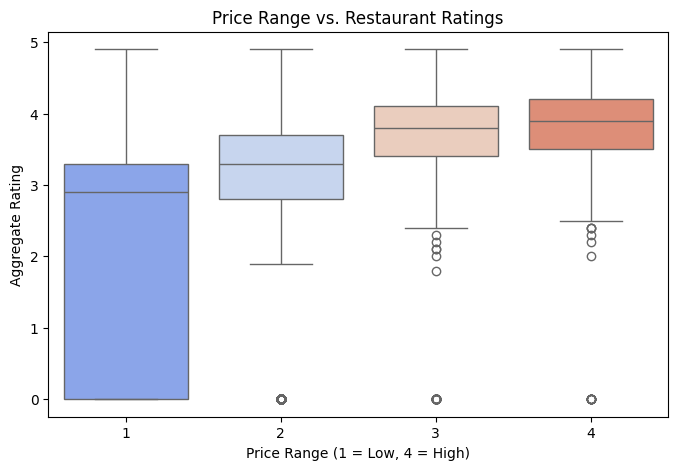

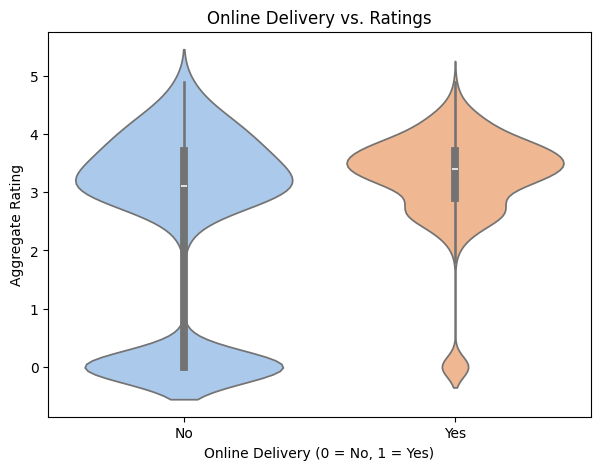

In [111]:
# Visualize the relationship between various features and the target variable to gain insights.
# Scatter plot: Votes vs. Ratings
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df["Votes"], y=df["Aggregate rating"], alpha=0.6, color="blue")
plt.title("Votes vs. Ratings")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")
plt.show()

# Boxplot: City-wise Rating Distribution
plt.figure(figsize=(12, 6))
top_cities = df.groupby("City")["Aggregate rating"].mean().nlargest(10).index
sns.boxplot(x="City", y="Aggregate rating", data=df[df["City"].isin(top_cities)], palette="coolwarm")
plt.xticks(rotation=45)
plt.title("City-wise Rating Distribution")
plt.xlabel("City")
plt.ylabel("Aggregate Rating")
plt.show()

# Bar plot: Cuisine-wise Average Ratings
plt.figure(figsize=(12, 6))
top_cuisines = df_expanded.groupby("Cuisines")["Aggregate rating"].mean().nlargest(10).index
sns.barplot(x="Aggregate rating", y="Cuisines", data=df_expanded[df_expanded["Cuisines"].isin(top_cuisines)], palette="viridis")
plt.title("Top Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Type")
plt.show()

# Box plot: price range wise aggregate rating
plt.figure(figsize=(8, 5))
sns.boxplot(x="Price range", y="Aggregate rating", data=df, palette="coolwarm")
plt.title("Price Range vs. Restaurant Ratings")
plt.xlabel("Price Range (1 = Low, 4 = High)")
plt.ylabel("Aggregate Rating")
plt.show()

# violinplot has online delivery wise rating
plt.figure(figsize=(7, 5))
sns.violinplot(x="Has Online delivery", y="Aggregate rating", data=df, palette="pastel")
plt.title("Online Delivery vs. Ratings")
plt.xlabel("Online Delivery (0 = No, 1 = Yes)")
plt.ylabel("Aggregate Rating")
plt.show()


# **Insights from the Visualizations:**
**1.Votes vs. Ratings:**

* Highly-rated restaurants tend to have more votes, suggesting a correlation between popularity and perceived quality.

* Some restaurants with high ratings have fewer votes, which may indicate niche appeal.

**2.City-wise Ratings:**

* Cities such as Inner City, Quezon City, and Makati City have the highest average ratings.

* This suggests that these locations have a high concentration of well-rated restaurants, possibly due to better service, food quality, or customer expectations.

**3.Cuisines vs. Ratings:**

* The highest-rated cuisines include Sunda, Bӧrek, and Taiwanese.

* Restaurants serving these cuisines may have unique offerings or a strong reputation among customers.

**4.Price Range vs. Ratings:**

* Higher-priced restaurants tend to have better ratings, indicating that customers associate price with quality.

* Lower-priced restaurants have a wider spread of ratings, suggesting inconsistency in quality.

**5.Online Delivery vs. Ratings:**

* Restaurants that offer online delivery tend to have slightly better ratings.

* This could indicate that convenience and accessibility improve customer satisfaction.

